In [1]:
import pandas as pd
df=pd.read_csv('antalya_hotels_final.csv', sep=';', encoding='utf-8-sig')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4337 entries, 0 to 4336
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   hotel_name                4337 non-null   object 
 1   district                  4337 non-null   object 
 2   hotel_type                4337 non-null   object 
 3   url                       4337 non-null   object 
 4   data_scraped_time         4337 non-null   object 
 5   latitude                  4337 non-null   float64
 6   longitude                 4337 non-null   object 
 7   original_price            4337 non-null   int64  
 8   discount_price_per_night  4337 non-null   int64  
 9   discount_rate             4337 non-null   float64
 10  room_type                 4337 non-null   object 
 11  max_occupancy             4337 non-null   int64  
 12  is_free_cancellable       4337 non-null   bool   
 13  breakfast                 4337 non-null   bool   
 14  parking 

,latitude,original_price,discount_price_per_night,discount_rate,max_occupancy,rating,num_reviews,weighted_rating,review_rating
count,4337.000000,4337.000000,4337.000000,4337.000000,4337.000000,4318.000000,4337.000000,4318.000000,4274.000000
mean,36.874439,9655.606641,7958.832603,0.136980,2.479594,8.417277,373.061333,8.436375,8.221806
std,0.038862,13478.151541,10757.469401,0.164947,0.647954,0.865828,356.716526,0.546469,2.488529
min,36.318599,1100.000000,1100.000000,0.000000,2.000000,4.000000,0.000000,5.806047,2.000000
25%,36.859693,4706.000000,3600.000000,0.000000,2.000000,8.000000,98.000000,8.151456,8.000000
50%,36.878419,6643.000000,5680.000000,0.050000,2.000000,8.600000,231.000000,8.498256,10.000000
75%,36.889227,8818.000000,7974.000000,0.260000,3.000000,9.000000,569.000000,8.750057,10.000000
max,36.967547,126477.000000,89799.000000,0.600000,10.000000,10.000000,1481.000000,9.494821,10.000000


In [2]:
# longitude sütunu, latitude gibi sayısal olmalı. Bunu düzeltelim.
# Hatalı karakter varsa NaN yapar.

df['longitude']= pd.to_numeric(df['longitude'],errors='coerce')

In [3]:
# tarih bilgisi içeren sütunları datetime formatına getirelim.
# dd.mm.yyyy formatında. bu yüzden ilk sayı günü belirtecek.

df['data_scraped_time']=pd.to_datetime(df['data_scraped_time'], dayfirst=True)

# eksik veriler olduğu için 'coerce' önemli.
df['review_date']=pd.to_datetime(df['review_date'], dayfirst=True, errors='coerce')

In [4]:
# review_text'i boş olan(yorum içermeyen) gözlemleri temizleyelim.
# inplace=True ile kalıcı hale getir.

df.dropna(subset=['review_text'], inplace=True)

In [5]:
print(df[['data_scraped_time','review_date']].dtypes)
print(f'Kalan Veri Sayısı:{len(df)}')

data_scraped_time    datetime64[ns]
review_date          datetime64[ns]
dtype: object
Kalan Veri Sayısı:4274


## 
Otel rating'i arttıkça fiyat veya indirim oranı nasıl değişiyor?

Korelasyon katsayısı, iki değişkenin birbirine ne kadar "bağlı" olduğunu gösterir. +1.0 'a yakınsa biri artarken diğeri de artıyor demektir (pozitif korelasyon).

[-1, +1]


In [6]:
# ilgilendiğimiz 3 özellik: rating, original_price, discount_rate

corr_table= df[['rating','original_price','discount_rate']].corr()
print(f"Korelasyon tablosu:\n{corr_table}")

Korelasyon tablosu:
                  rating  original_price  discount_rate
rating          1.000000        0.222247       0.185577
original_price  0.222247        1.000000       0.169198
discount_rate   0.185577        0.169198       1.000000


## scatter plot - regression
ilişkiyi grafik üzerinde görelim.

sns.regplot, her oteli bir nokta olarak gösterir ve aralarından geçen en uygun eğilim çizgisini çizer.

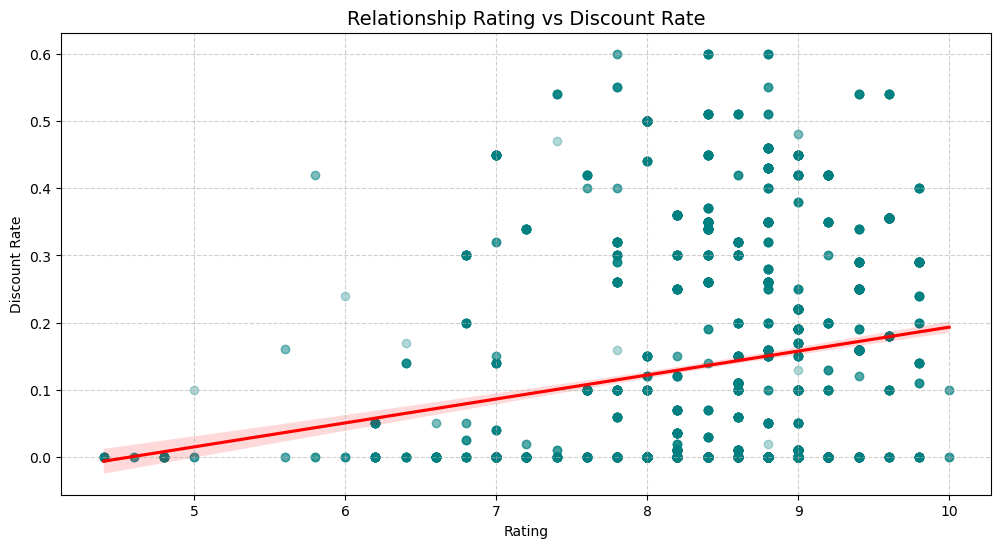

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# rating- discount_rate ilişkisi
sns.regplot(data=df, x='rating', y='discount_rate', 
           scatter_kws={'alpha':0.3, 'color':'teal'},
           line_kws={'color':'red'})

plt.title("Relationship Rating vs Discount Rate", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Discount Rate")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 
rating ve discount rate arasında pozitif ama zayıf bir korelasyon vardır.

Yüksek rating'li oteller erken rezervasyon döneminde stratejik indirimler uygulamaktadır ve bu indirimli fiyatlar müşteri üzerinde küçük olumlu bir etki yaratmaktadır.

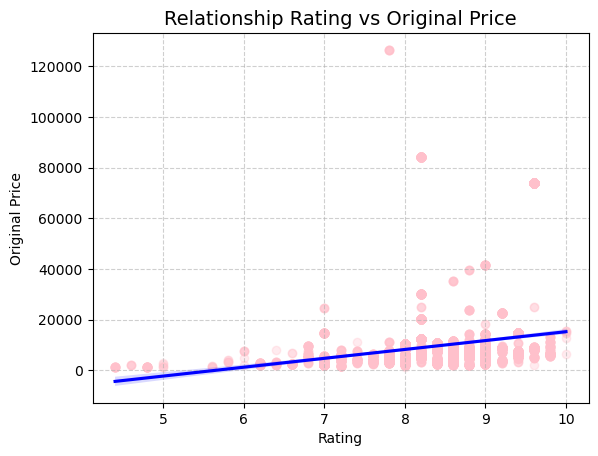

In [8]:
# rating- original_price ilişkisi
sns.regplot(data=df, x='rating', y='original_price',
           scatter_kws={'alpha':0.3, 'color':'pink'},
           line_kws={'color':'blue'})

plt.title("Relationship Rating vs Original Price", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Original Price")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 
Grafiğin üst kısmındaki 3 nokta, outlier(aykırı değer). Çok yüksek fiyatlı olmalarına rağmen, çok yüksek rating alamamışlar.

Yüksek fiyat, her zaman yüksek puanlama getirmemektedir. Outlier'ların ortalama bir rating'e sahip olması, bunu kanıtlamaktadır.

Yüksek fiyat, müşteride daha yüksek hizmet beklentisi yaratmaktadır.

##
Market Analysis

Dataset'te spa, pool gibi binary bilgiler var. Bunların fiyat (original_price) üzerindeki etkisini inceleyelim.

impact = etki : Bağımsız bir değişkenin, bağımlı değişken üzerindeki istatistiksel ağırlığıdır.

Örneğin otelde havuz olması fiyatı nasıl etkiliyor?

Her bir özelliği gezip True ve False durumları için ortalama fiyatları hesaplayacak, ardından bunlar DataFrame'de toplanacak.

In [10]:
# Analiz edilecek özellikler
features=['breakfast','pool','spa','parking','is_free_cancellable']

# Sonuçları tutmak için boş bir liste oluşturalım.
impact_data=[]

for i in features:
    # her özellik için ortalama fiyat hesabı
    mean_price=df.groupby(i)['discount_price_per_night'].mean()

    # verileri düzenli bir formatta ekle
    impact_data.append(
        {'Feature': i,
         'False_mean_price': mean_price[False],  # o özelliğin olmadığı durumda fiyat
         'True_mean_price': mean_price[True],    # o özelliğin olduğu durumda fiyat
         'Price_difference': mean_price[True] - mean_price[False]  # o özelliğin yarattığı fiyat farkı           
        }
    )

# sonuçları bir DataFrame'de görelim.
impact_df= pd.DataFrame(impact_data)

# Fark sütununa göre büyükten küçüğe sıralayıp EN ANLAMLI ÖZELLİĞİ görelim.
impact_df= impact_df.sort_values(by='Price_difference',ascending=False)

print("Impact of Amenities on Pricing")
print(impact_df.to_string(index=False))

Impact of Amenities on Pricing
            Feature  False_mean_price  True_mean_price  Price_difference
                spa       5104.191116     12789.727900       7685.536784
               pool       4794.501905     10367.765285       5573.263380
          breakfast       4994.914333      8465.184347       3470.270014
            parking       5689.701195      8276.117179       2586.415984
is_free_cancellable       7997.180614      7921.642959        -75.537655


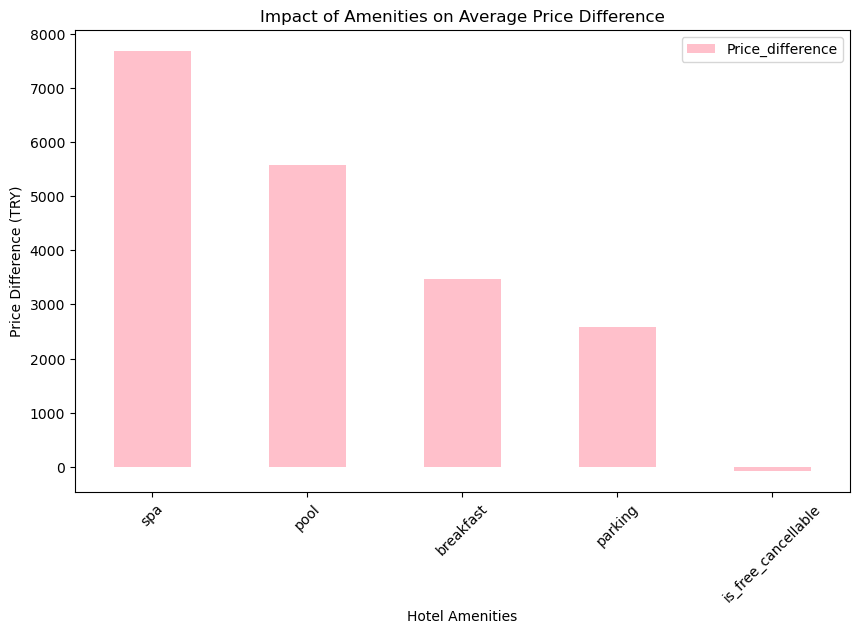

In [11]:
import matplotlib.pyplot as plt

impact_df.plot(kind='bar', x='Feature', y='Price_difference', color='pink', figsize=(10,6))
plt.title('Impact of Amenities on Average Price Difference') # Hangi Özellik Fiyatı Ne Kadar Artırıyor?
plt.ylabel('Price Difference (TRY)') # Fiyat Farkı (TRY)
plt.xlabel('Hotel Amenities') # Otel Özellikleri
plt.xticks(rotation=45)
plt.show()

### 
spa, Antalya pazarında 'Premium/Lüks' segmenti belirleyen ana kriterdir.

parking gibi çoğu otelde bulunan temel hizmetlerin fiyat farkı daha düşükken, daha nadir bulunan spa ve pool gibi özelliklerin fiyat üzerindeki etkisi çok daha yüksektir.

is_free_cancellable özelliğinin fiyata etkisinin yok denecek kadar az olması, bu özelliğin oteller tarafından sunulan bir müşteri memnuniyeti aracı olarak kullanıldığını ortaya koymaktadır.

In [13]:
# temizlenmiş veriyi kaydet.
df.to_csv('hotels_cleaned.csv', index=False, sep=';', encoding='utf-8-sig')
print("EDA aşaması tamamlandı ve yeni csv dosyasına kaydedildi")

EDA aşaması tamamlandı ve yeni csv dosyasına kaydedildi
